In [141]:
import pandas as pd
import sqlite3

## uploading data from database from table checking

In [142]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [143]:
checker = pd.read_sql(
    '''
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%'
''', conn, parse_dates='timestamp'
)
checker

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


## split the data for weekends and working days

In [144]:
checker['type_of_day'] = checker.timestamp.apply(lambda date: 'working_day' if date.weekday() < 5 else 'weekend')

In [145]:
checker

,timestamp,type_of_day
0,2020-04-17 05:19:02.744528,working_day
1,2020-04-17 05:22:35.249331,working_day
2,2020-04-17 05:22:45.549397,working_day
3,2020-04-17 05:34:14.691200,working_day
4,2020-04-17 05:34:24.422370,working_day
...,...,...
3202,2020-05-21 20:19:06.872761,working_day
3203,2020-05-21 20:22:41.785725,working_day
3204,2020-05-21 20:22:41.877806,working_day
3205,2020-05-21 20:37:00.129678,working_day


## get a table with the number of commits by hour for every type of day

In [191]:
checker['date'] = checker.timestamp.dt.date
checker['hour'] = checker.timestamp.dt.hour
checker

,timestamp,type_of_day,date,hour
0,2020-04-17 05:19:02.744528,working_day,2020-04-17,5
1,2020-04-17 05:22:35.249331,working_day,2020-04-17,5
2,2020-04-17 05:22:45.549397,working_day,2020-04-17,5
3,2020-04-17 05:34:14.691200,working_day,2020-04-17,5
4,2020-04-17 05:34:24.422370,working_day,2020-04-17,5
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,working_day,2020-05-21,20
3203,2020-05-21 20:22:41.785725,working_day,2020-05-21,20
3204,2020-05-21 20:22:41.877806,working_day,2020-05-21,20
3205,2020-05-21 20:37:00.129678,working_day,2020-05-21,20


In [198]:
commits_grouped = checker.groupby(['type_of_day', 'date', 'hour']).count()
commits_grouped = commits_grouped.groupby(
    ['type_of_day', 'hour']).mean().reset_index()
commits_grouped

,type_of_day,hour,timestamp
0,weekend,0,2.000000
1,weekend,1,6.000000
2,weekend,3,1.000000
3,weekend,5,2.000000
4,weekend,7,4.000000
5,weekend,8,7.000000
6,weekend,9,3.666667
7,weekend,10,7.000000
8,weekend,11,23.600000
9,weekend,12,9.500000


In [201]:
pivot_table = pd.pivot(commits_grouped,
                       values='timestamp',
                       index='hour',
                       columns='type_of_day')
pivot_table.fillna(0)

type_of_day,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,0.000000
3,1.000000,2.000000
5,2.000000,7.500000
6,0.000000,1.500000
7,4.000000,5.166667
8,7.000000,3.700000
9,3.666667,6.000000
10,7.000000,13.200000


## bar graph

array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'working_day'}, xlabel='hour'>],
      dtype=object)

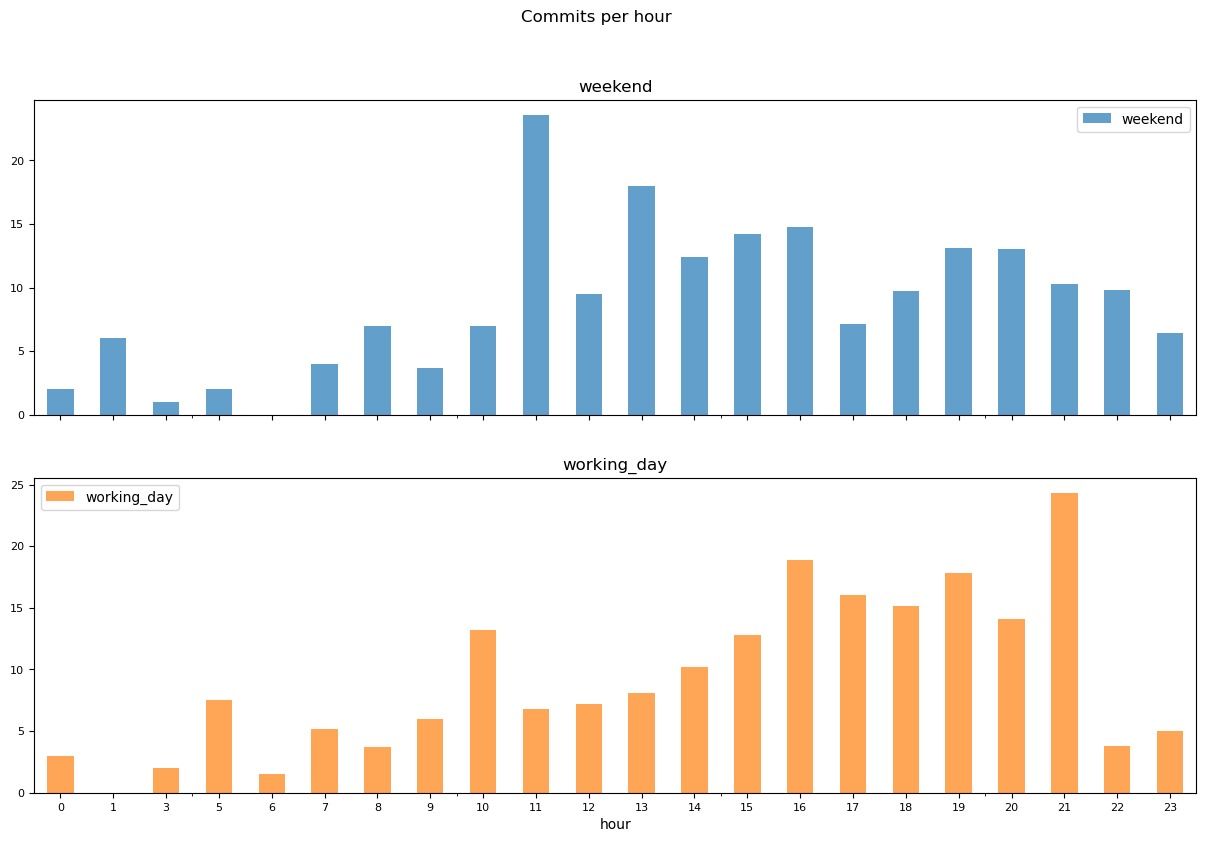

In [207]:
pivot_table.plot(kind='bar',
                 subplots=True,
                 figsize=(15,9),
                 rot=0,
                 fontsize=8,
                 title='Commits per hour',
                 alpha=0.7)

## Is the dynamic different on working days and weekends ?

In [220]:
pivot_table.weekend.idxmax()

11

In [221]:
pivot_table.working_day.idxmax()

21

## hours when in weeknd commits more than in working days : [8, 11, 12, 13, 14, 15, 22, 23]

## hour when the number of commits is the largest during working days : 21
## the hour when it is the largest during the weekend : 11

In [222]:
conn.close()